# Forward-Backward Representation Learning — Four Rooms GridWorld



In [1]:
# Standard library
from pathlib import Path
import sys
import copy

# Resolve repository src path robustly when running the notebook from any location
repo_root = Path.cwd()
while repo_root != repo_root.parent and not (repo_root / 'src').exists():
    repo_root = repo_root.parent
sys.path.insert(0, str(repo_root / 'src'))

# Third-party
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
import matplotlib.pyplot as plt
from IPython.display import clear_output

# Project modules
from environments.fourrooms_discrete import FourRoomsGridWorld, FourRoomsGoalWrapper
from utils import TrajectoryReplayBufferDiscrete
from visualisations import plot_policy_rollouts, plot_q_diagnostics

print(f"PyTorch version : {torch.__version__}")
print(f"NumPy   version : {np.__version__}")


PyTorch version : 2.12.0
NumPy   version : 2.4.4


In [2]:
class ForwardNetwork(nn.Module):
    """
    Forward feature network   F(s, a) -> R^d

    Input  : concatenation of observation s and one-hot encoded action a.
    Output : d-dimensional forward embedding.

    The Q-value for goal g is:  Q(s, a; g) = F(s, a)^T B(g)
    """

    def __init__(self, obs_dim: int, num_actions: int,
                 embed_dim: int = 64, hidden_dim: int = 256, n_hidden: int = 2):
        super().__init__()
        in_dim = obs_dim + num_actions
        self.fc_in  = nn.Linear(in_dim, hidden_dim)
        self.hidden = nn.ModuleList(
            [nn.Linear(hidden_dim, hidden_dim) for _ in range(n_hidden)]
        )
        self.fc_out = nn.Linear(hidden_dim, embed_dim)

    def forward(self, obs: torch.Tensor, action_onehot: torch.Tensor) -> torch.Tensor:
        """
        Args:
            obs           : [B, obs_dim]     -- current state
            action_onehot : [B, num_actions] -- one-hot encoded discrete action
        Returns:
            [B, embed_dim]  -- forward embedding F(s, a)
        """
        x = torch.cat([obs, action_onehot], dim=-1)   # [B, obs_dim + num_actions]
        x = F.relu(self.fc_in(x))
        for layer in self.hidden:
            x = F.relu(layer(x))
        return self.fc_out(x)                          # [B, embed_dim]


class BackwardNetwork(nn.Module):
    """
    Backward feature network   B(s) -> R^d

    Input  : observation s.
    Output : d-dimensional backward embedding.

    When evaluated at the goal state g, B(g) serves as the
    goal direction vector z:  Q(s, a; g) = F(s, a)^T z,  z = B(g)
    """

    def __init__(self, obs_dim: int, embed_dim: int = 64,
                 hidden_dim: int = 256, n_hidden: int = 2):
        super().__init__()
        self.fc_in  = nn.Linear(obs_dim, hidden_dim)
        self.hidden = nn.ModuleList(
            [nn.Linear(hidden_dim, hidden_dim) for _ in range(n_hidden)]
        )
        self.fc_out = nn.Linear(hidden_dim, embed_dim)

    def forward(self, obs: torch.Tensor) -> torch.Tensor:
        """
        Args:
            obs : [B, obs_dim] -- state
        Returns:
            [B, embed_dim]  -- backward embedding B(s)
        """
        x = F.relu(self.fc_in(obs))
        for layer in self.hidden:
            x = F.relu(layer(x))
        return self.fc_out(x)                          # [B, embed_dim]


print("ForwardNetwork and BackwardNetwork defined.")


ForwardNetwork and BackwardNetwork defined.


In [ ]:
# Hyperparameters
TOTAL_ENV_STEPS   = 100000   # total environment interaction steps
WARMUP_STEPS      = 5000     # random exploration before policy learning
BATCH_SIZE        = 256       # mini-batch size for each gradient update
GAMMA             = 0.99      # discount factor
LR                = 1e-3      # Adam learning rate for F and B networks
TAU               = 0.005     # Polyak coefficient for target network updates
EMBED_DIM         = 64        # latent dimensionality d
HIDDEN_DIM        = 256       # MLP hidden layer width
N_HIDDEN          = 2         # number of hidden layers
ORTHO_COEF        = 0.5       # coefficient lambda_orth for orthonormality regulariser
HINDSIGHT_FRAC    = 0.5       # fraction of goals sampled as hindsight (s_g = s')
EPS_START         = 1.0       # initial epsilon for epsilon-greedy exploration
EPS_END           = 0.05      # final epsilon
EPS_DECAY_STEPS   = 50000    # linear decay window for epsilon
BUFFER_CAPACITY   = 100000   # replay buffer capacity
TRAIN_FREQ        = 4         # gradient updates per environment step
LOG_INTERVAL      = 200       # logging / plotting interval (gradient steps)
MAX_EPISODE_STEPS = 500       # maximum steps per episode
SLIP_PROB         = 0.0       # action slip probability (0 = deterministic)
GOAL_POS          = (9, 9)    # training goal position (top-right room)

DEVICE = (
    "mps"  if torch.backends.mps.is_available()  else
    "cuda" if torch.cuda.is_available()           else
    "cpu"
)
print(f"Device: {DEVICE}")

# Environment
base_env  = FourRoomsGridWorld(room_size=5, max_episode_steps=MAX_EPISODE_STEPS)
env_train = FourRoomsGoalWrapper(
    base_env,
    goal_position=GOAL_POS,
    goal_reward=1.0,
    step_reward=0.0,
    slip_prob=SLIP_PROB,
)

obs_dim     = env_train.observation_space.shape[0]  # 2  (x, y coordinates)
num_actions = env_train.action_space.n               # 4  (Up/Down/Left/Right)
print(f"obs_dim = {obs_dim},  num_actions = {num_actions}")

# Forward and Backward networks
F_net = ForwardNetwork(obs_dim, num_actions, EMBED_DIM, HIDDEN_DIM, N_HIDDEN).to(DEVICE)
B_net = BackwardNetwork(obs_dim, EMBED_DIM, HIDDEN_DIM, N_HIDDEN).to(DEVICE)

# Target networks: Polyak-updated copies, not directly gradient-updated
F_tgt = copy.deepcopy(F_net)
B_tgt = copy.deepcopy(B_net)
for p in F_tgt.parameters(): p.requires_grad_(False)
for p in B_tgt.parameters(): p.requires_grad_(False)

# Single Adam optimiser for both F and B (they share the FB objective)
optimizer = optim.Adam(
    list(F_net.parameters()) + list(B_net.parameters()), lr=LR
)

# Replay buffer (discrete action variant from utils.py)
replay_buffer = TrajectoryReplayBufferDiscrete(
    capacity=BUFFER_CAPACITY,
    obs_dim=obs_dim,
    action_dim=1,   # discrete: stored as int64
    device=DEVICE,
)

# Training history for plotting
fb_loss_history    = []
ortho_loss_history = []
ep_len_history     = []
ep_return_history  = []
env_steps_log      = []

grad_step       = 0
total_env_steps = 0

print("Setup complete.")
print(f"  F_net parameters : {sum(p.numel() for p in F_net.parameters()):,}")
print(f"  B_net parameters : {sum(p.numel() for p in B_net.parameters()):,}")


Device: mps
obs_dim = 2,  num_actions = 4
Setup complete.
  F_net parameters : 149,824
  B_net parameters : 148,800


In [4]:
# Utility helpers

def onehot(actions: torch.Tensor, num_classes: int = 4) -> torch.Tensor:
    """One-hot encode a batch of integer actions.  Returns [B, num_classes]."""
    return F.one_hot(actions.long(), num_classes=num_classes).float()


def compute_all_action_q(
    obs: torch.Tensor,
    z: torch.Tensor,
    F_net_used: nn.Module,
    num_actions: int = 4,
) -> torch.Tensor:
    """
    Compute Q(s, a; z) = F(s, a)^T z  for every discrete action a.

    Performs one forward pass of F per action and stacks results.

    Args:
        obs         : [B, obs_dim]  -- current states
        z           : [B, d]        -- goal direction vectors  (z = B(s_goal))
        F_net_used  : ForwardNetwork instance
        num_actions : number of discrete actions

    Returns:
        [B, num_actions]  -- Q-value for every action
    """
    B_size = obs.shape[0]
    device = obs.device
    q_list = []
    for a in range(num_actions):
        a_oh = F.one_hot(
            torch.full((B_size,), a, dtype=torch.long, device=device),
            num_classes=num_actions,
        ).float()                                   # [B, num_actions]
        F_sa = F_net_used(obs, a_oh)                # [B, d]
        q_a  = (F_sa * z).sum(dim=-1)              # [B]   dot product per sample
        q_list.append(q_a)
    return torch.stack(q_list, dim=1)               # [B, num_actions]


def compute_epsilon(
    step: int,
    eps_start: float = EPS_START,
    eps_end: float   = EPS_END,
    decay_steps: int = EPS_DECAY_STEPS,
) -> float:
    """Linearly decay epsilon from eps_start to eps_end over decay_steps steps."""
    fraction = min(step / decay_steps, 1.0)
    return eps_start + fraction * (eps_end - eps_start)


def epsilon_greedy(
    obs_np: np.ndarray,
    goal_obs_np: np.ndarray,
    epsilon: float,
    F_net_used: nn.Module,
    B_net_used: nn.Module,
    device: str,
    num_actions: int = 4,
) -> int:
    """
    epsilon-greedy action selection using the FB Q-value.

    With probability epsilon  -> take a uniformly random action.
    Otherwise                 -> take the greedy action: a* = argmax_a F(s,a)^T B(g)

    Args:
        obs_np      : [obs_dim]  -- current observation (numpy)
        goal_obs_np : [obs_dim]  -- goal state position (numpy)
        epsilon     : exploration rate in [0, 1]

    Returns:
        action (int)
    """
    if np.random.rand() < epsilon:
        return int(np.random.randint(num_actions))

    obs_t  = torch.tensor(obs_np,      dtype=torch.float32, device=device).unsqueeze(0)  # [1, 2]
    goal_t = torch.tensor(goal_obs_np, dtype=torch.float32, device=device).unsqueeze(0)  # [1, 2]

    with torch.no_grad():
        z = B_net_used(goal_t)                                       # [1, d]
        q = compute_all_action_q(obs_t, z, F_net_used, num_actions)  # [1, num_actions]

    return int(q.argmax(dim=-1).item())


def collect_episode(env, policy_fn):
    """
    Roll out one full episode and return the transition dictionary.

    Args:
        env       : gymnasium environment
        policy_fn : callable  obs_np -> action (int)

    Returns:
        (episode_dict, episode_length, total_return)
    """
    obs_t, _ = env.reset()
    done      = False
    ep        = {k: [] for k in ["obs", "actions", "rewards",
                                  "next_obs", "terminated", "truncated"]}
    ep_return = 0.0

    while not done:
        action         = policy_fn(obs_t)
        next_obs_t, reward, term, trunc, _ = env.step(action)

        ep["obs"].append(obs_t.astype(np.float32))
        ep["actions"].append(np.int64(action))
        ep["rewards"].append(np.float32(reward))
        ep["next_obs"].append(next_obs_t.astype(np.float32))
        ep["terminated"].append(np.float32(term))
        ep["truncated"].append(np.float32(trunc))

        ep_return += float(reward)
        obs_t      = next_obs_t
        done       = term or trunc

    return ep, len(ep["obs"]), ep_return


# Core training step

def fb_training_step(
    replay_buf,
    F_net_used:  nn.Module,
    B_net_used:  nn.Module,
    F_tgt_used:  nn.Module,
    B_tgt_used:  nn.Module,
    opt:         optim.Optimizer,
    batch_size:  int   = BATCH_SIZE,
    gamma:       float = GAMMA,
    ortho_coef:  float = ORTHO_COEF,
    h_frac:      float = HINDSIGHT_FRAC,
    num_actions: int   = 4,
    embed_dim:   int   = EMBED_DIM,
    device:      str   = DEVICE,
):
    """
    Execute one FB gradient update.

    Steps:
    1. Sample mini-batch (s, a, s', done) from replay buffer.
    2. Sample goals:
         h_frac     of goals -> s_g = s'         (hindsight, delta = 1)
         1 - h_frac of goals -> s_g ~ buffer     (random,    delta ~= 0)
    3. Compute Bellman target using target networks F_tgt, B_tgt:
         target = delta(s' = s_g) + gamma*(1-done) * max_a' F_tgt(s',a')^T B_tgt(s_g)
    4. Compute prediction:
         pred   = F(s, a)^T B(s_g)
    5. FB loss:    L_FB   = MSE(pred, target)
    6. Ortho loss: L_orth = ||B(s_rand)^T B(s_rand)/N - I||^2_F
    7. Total loss: L      = L_FB + ortho_coef * L_orth
    8. Backprop + gradient clipping (max-norm 10.0) + optimiser step.

    Returns:
        (fb_loss_value, ortho_loss_value)  -- scalar floats for logging
    """
    # 1. Sample transitions
    batch    = replay_buf.sample(batch_size)
    obs      = batch.obs                                     # [B, 2]
    actions  = batch.actions                                 # [B]  int64
    next_obs = batch.next_obs                                # [B, 2]
    # done = 1.0 if episode ended (terminated OR truncated)
    done     = (batch.terminated + batch.truncated).clamp(0, 1)  # [B, 1]

    # 2. Sample goals: hindsight (s_g = s') and random
    n_hint = int(batch_size * h_frac)
    n_rand = batch_size - n_hint

    # Hindsight goals: s_g = s'  =>  delta(s' = s_g) = 1 by construction
    goals_h     = next_obs[:n_hint]                          # [n_hint, 2]
    indicator_h = torch.ones(n_hint, device=device)          # delta = 1

    # Random goals: delta fires only if sampled goal accidentally matches s'
    goals_r     = replay_buf.sample_random_goals(n_rand)     # [n_rand, 2]
    indicator_r = (
        next_obs[n_hint:].round().int() == goals_r.round().int()
    ).all(dim=-1).float()                                    # [n_rand]

    goals     = torch.cat([goals_h, goals_r], dim=0)         # [B, 2]
    indicator = torch.cat([indicator_h, indicator_r], dim=0) # [B]

    # 3. Prediction:  pred = F(s, a)^T B(s_g)
    a_oh   = onehot(actions, num_classes=num_actions)         # [B, 4]
    phi_sa = F_net_used(obs, a_oh)                            # [B, d]  forward features
    psi_g  = B_net_used(goals)                                # [B, d]  backward features
    pred   = (phi_sa * psi_g).sum(dim=-1)                     # [B]     dot product

    # 4. Bellman target with target networks (no gradient through target)
    with torch.no_grad():
        psi_g_tgt = B_tgt_used(goals)                         # [B, d]

        # Q-values at next state for all actions: F_tgt(s',a')^T B_tgt(s_g)
        q_next = compute_all_action_q(
            next_obs, psi_g_tgt, F_tgt_used, num_actions
        )                                                      # [B, num_actions]
        q_next_max = q_next.max(dim=-1).values                # [B]

        # Bellman target:  delta + gamma*(1-done)*max_a' Q(s',a')
        target = indicator + gamma * (1.0 - done.squeeze(-1)) * q_next_max  # [B]

    # 5. FB Bellman loss  (MSE)
    fb_loss = F.mse_loss(pred, target)

    # 6. Orthonormality regulariser
    #    Sample a fresh batch of random states to estimate the Gram matrix
    s_rand     = replay_buf.sample_random_goals(batch_size)   # [B, 2]
    B_rand     = B_net_used(s_rand)                           # [B, d]
    gram       = B_rand.T @ B_rand / batch_size               # [d, d]  empirical Gram matrix
    I_d        = torch.eye(embed_dim, device=device)
    ortho_loss = ((gram - I_d) ** 2).sum()                    # Frobenius norm squared

    # 7. Total loss
    total_loss = fb_loss + ortho_coef * ortho_loss

    # 8. Optimisation step
    opt.zero_grad()
    total_loss.backward()
    nn.utils.clip_grad_norm_(
        list(F_net_used.parameters()) + list(B_net_used.parameters()),
        max_norm=10.0,
    )
    opt.step()

    return fb_loss.item(), ortho_loss.item()


print("All helper functions defined.")


All helper functions defined.


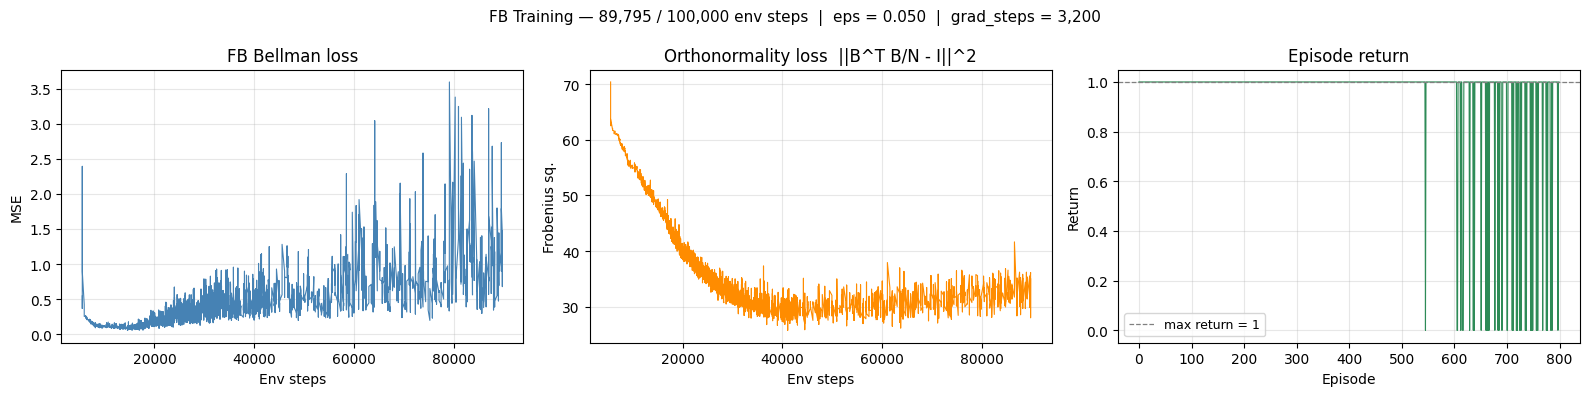

Training complete!
  Total env steps  : 100,039
  Gradient steps   : 3,340
  Buffer size      : 100,000


In [5]:
# Goal observation used during epsilon-greedy training exploration
goal_obs_np = np.array(GOAL_POS, dtype=np.float32)

# Phase 1: Warm-up (random policy)
print(f"Warm-up: collecting {WARMUP_STEPS:,} random-action steps ...")

random_policy = lambda obs: int(np.random.randint(num_actions))

while total_env_steps < WARMUP_STEPS:
    ep, ep_steps, ep_ret = collect_episode(env_train, random_policy)
    replay_buffer.add_episode(ep)
    total_env_steps += ep_steps

print(f"Warm-up done.  Buffer: {replay_buffer.size:,} transitions, "
      f"{total_env_steps:,} env steps.\n")

# Phase 2: Main training loop
while total_env_steps < TOTAL_ENV_STEPS:

    # Current exploration rate (decays linearly)
    epsilon = compute_epsilon(total_env_steps)

    # Collect one episode with epsilon-greedy policy
    def policy_fn(obs):
        return epsilon_greedy(
            obs, goal_obs_np, epsilon, F_net, B_net, DEVICE, num_actions
        )

    ep, ep_steps, ep_ret = collect_episode(env_train, policy_fn)
    replay_buffer.add_episode(ep)
    total_env_steps += ep_steps
    ep_len_history.append(ep_steps)
    ep_return_history.append(ep_ret)

    # TRAIN_FREQ gradient updates
    for _ in range(TRAIN_FREQ):
        grad_step += 1

        fb_l, orth_l = fb_training_step(
            replay_buffer, F_net, B_net, F_tgt, B_tgt, optimizer
        )
        fb_loss_history.append(fb_l)
        ortho_loss_history.append(orth_l)
        env_steps_log.append(total_env_steps)

        # Polyak update: F_tgt <- tau*F + (1-tau)*F_tgt
        #                B_tgt <- tau*B + (1-tau)*B_tgt
        with torch.no_grad():
            for p, p_t in zip(F_net.parameters(), F_tgt.parameters()):
                p_t.data.mul_(1.0 - TAU).add_(TAU * p.data)
            for p, p_t in zip(B_net.parameters(), B_tgt.parameters()):
                p_t.data.mul_(1.0 - TAU).add_(TAU * p.data)

    # Live progress plot every LOG_INTERVAL gradient steps
    if grad_step % LOG_INTERVAL == 0:
        clear_output(wait=True)
        fig, axes = plt.subplots(1, 3, figsize=(16, 4))

        axes[0].plot(env_steps_log, fb_loss_history, color='steelblue', linewidth=0.8)
        axes[0].set_title("FB Bellman loss")
        axes[0].set_xlabel("Env steps");  axes[0].set_ylabel("MSE")
        axes[0].grid(alpha=0.3)

        axes[1].plot(env_steps_log, ortho_loss_history, color='darkorange', linewidth=0.8)
        axes[1].set_title("Orthonormality loss  ||B^T B/N - I||^2")
        axes[1].set_xlabel("Env steps");  axes[1].set_ylabel("Frobenius sq.")
        axes[1].grid(alpha=0.3)

        axes[2].plot(ep_return_history, color='seagreen', linewidth=0.8)
        axes[2].axhline(1.0, color='gray', linestyle='--', linewidth=0.9, label='max return = 1')
        axes[2].set_title("Episode return")
        axes[2].set_xlabel("Episode");  axes[2].set_ylabel("Return")
        axes[2].legend(fontsize=9);  axes[2].grid(alpha=0.3)

        plt.suptitle(
            f"FB Training — {total_env_steps:,} / {TOTAL_ENV_STEPS:,} env steps"
            f"  |  eps = {epsilon:.3f}  |  grad_steps = {grad_step:,}",
            fontsize=11,
        )
        plt.tight_layout();  plt.show()

# Cleanup
env_train.close()
print("Training complete!")
print(f"  Total env steps  : {total_env_steps:,}")
print(f"  Gradient steps   : {grad_step:,}")
print(f"  Buffer size      : {replay_buffer.stats()['size']:,}")


---
## 7 · Post-Training Analysis

We evaluate the trained FB representation in three ways:

1. **Smoothed training curves** — overall convergence trends without per-step noise.
2. **Q-value heatmap** via `plot_q_diagnostics`:
   - *Left panel*:   max Q(s, a; goal) over actions — the implicit value function.
   - *Middle panel*: greedy action `argmax_a Q(s,a;goal)` — the learned policy map.
   - *Right panel*:  episode return curve.
3. **Policy rollouts** via `plot_policy_rollouts` — actual agent trajectories
   toward the training goal `(9, 9)`.

For the Q-value computations we define a wrapper `fb_value_fn` that evaluates

$$Q(s, a;\, g) = F(s, a)^\top B(g) \quad \text{for all } a \in \{0,1,2,3\}$$

with the fixed training goal embedding `z_goal = B((9, 9))`.


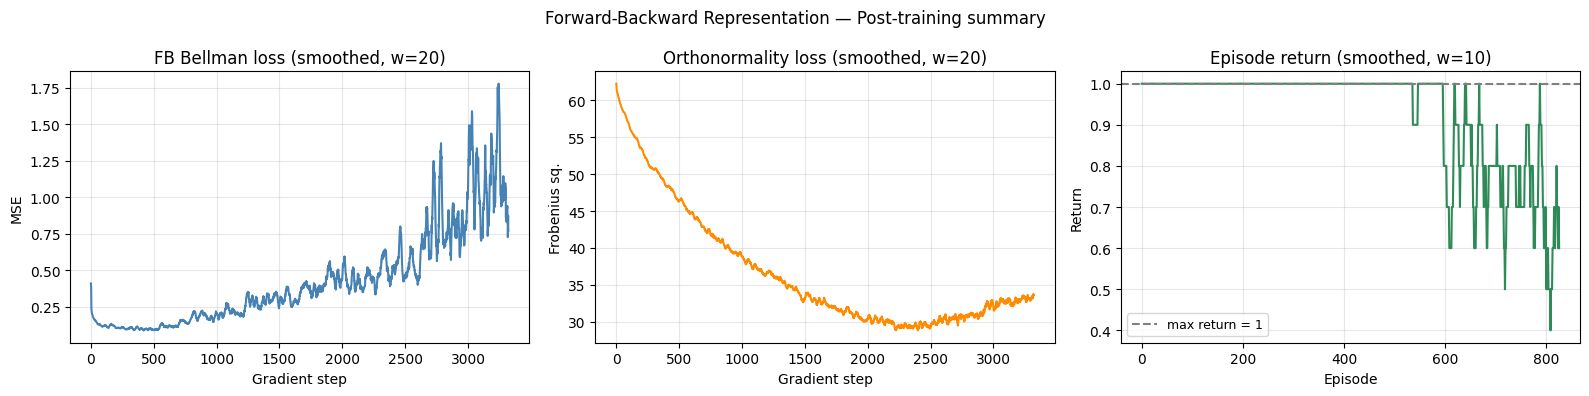

In [6]:
def smooth(x, w=20):
    """Simple rolling-mean smoother for 1D sequences."""
    return np.convolve(x, np.ones(w) / w, mode='valid')


fig, axes = plt.subplots(1, 3, figsize=(16, 4))

axes[0].plot(smooth(fb_loss_history),    color='steelblue')
axes[0].set_title("FB Bellman loss (smoothed, w=20)")
axes[0].set_xlabel("Gradient step");  axes[0].set_ylabel("MSE")
axes[0].grid(alpha=0.3)

axes[1].plot(smooth(ortho_loss_history), color='darkorange')
axes[1].set_title("Orthonormality loss (smoothed, w=20)")
axes[1].set_xlabel("Gradient step");  axes[1].set_ylabel("Frobenius sq.")
axes[1].grid(alpha=0.3)

axes[2].plot(smooth(ep_return_history, w=10), color='seagreen')
axes[2].axhline(1.0, color='gray', linestyle='--', label='max return = 1')
axes[2].set_title("Episode return (smoothed, w=10)")
axes[2].set_xlabel("Episode");  axes[2].set_ylabel("Return")
axes[2].legend(fontsize=9);  axes[2].grid(alpha=0.3)

plt.suptitle("Forward-Backward Representation — Post-training summary", fontsize=12)
plt.tight_layout();  plt.show()


### Q-value Heatmap and Policy Map (Training Goal)

We construct a `fb_value_fn` wrapper that computes
$$Q(s, a;\, g) = F(s, a)^\top B(g)$$
for all four actions simultaneously, with the fixed training goal `g = (9, 9)`.

This is passed to `plot_q_diagnostics` from `src/visualisations.py`, which sweeps
over every non-wall grid cell and produces the heatmap panels.


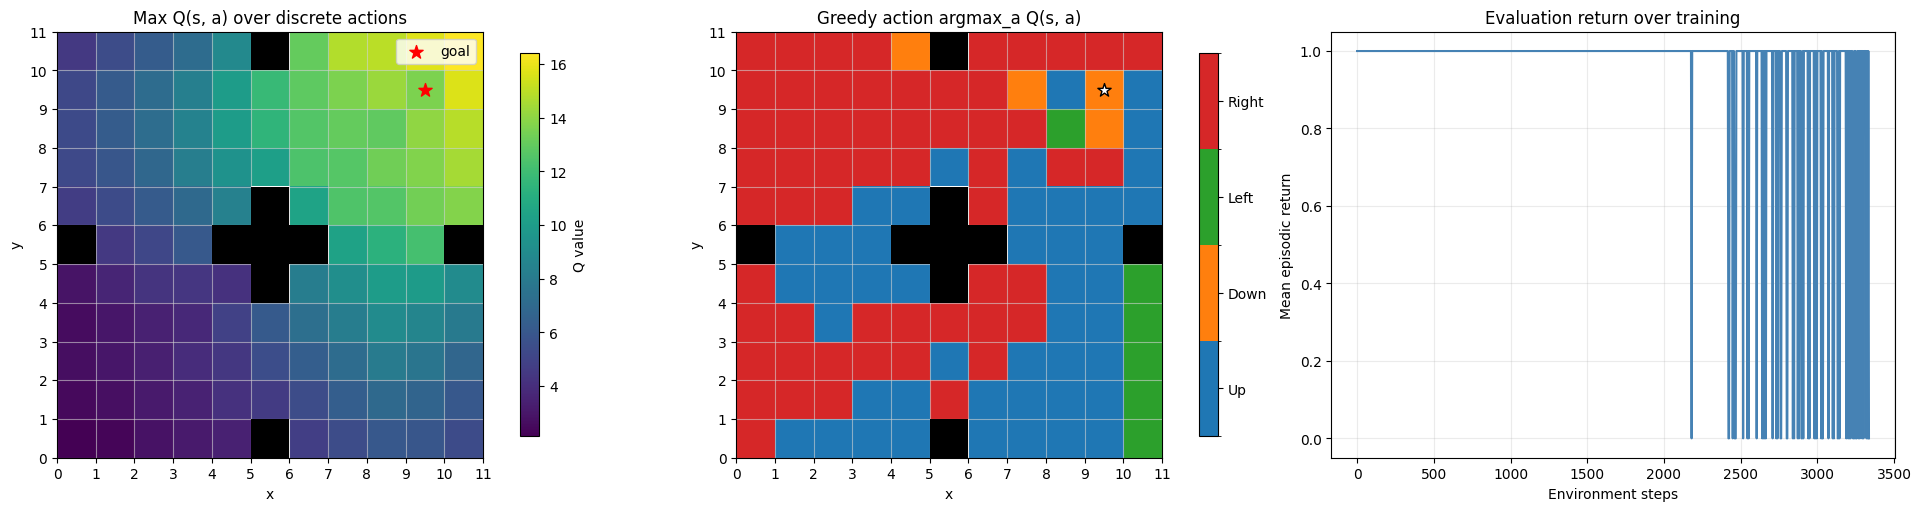

BackwardNetwork(
  (fc_in): Linear(in_features=2, out_features=256, bias=True)
  (hidden): ModuleList(
    (0-1): 2 x Linear(in_features=256, out_features=256, bias=True)
  )
  (fc_out): Linear(in_features=256, out_features=64, bias=True)
)

In [7]:
# Fresh evaluation environment
base_eval = FourRoomsGridWorld(room_size=5, max_episode_steps=MAX_EPISODE_STEPS)
env_eval  = FourRoomsGoalWrapper(
    base_eval, goal_position=GOAL_POS, goal_reward=1.0, step_reward=0.0
)

# Pre-compute goal embedding  z_goal = B(s_goal)
goal_tensor = torch.tensor(
    list(GOAL_POS), dtype=torch.float32, device=DEVICE
).unsqueeze(0)                                                # [1, 2]

F_net.eval();  B_net.eval()
with torch.no_grad():
    z_goal = B_net(goal_tensor)                               # [1, d]  goal direction


def fb_value_fn(obs_batch: np.ndarray) -> np.ndarray:
    """
    Compute Q(s, a; goal) for all 4 actions given the training goal.

    Used by plot_q_diagnostics (discrete mode).

    Args:
        obs_batch : [N, 2]  numpy array of (x, y) grid positions
    Returns:
        [N, 4]  numpy array of Q-values, one column per action
    """
    obs_t = torch.tensor(
        np.asarray(obs_batch), dtype=torch.float32, device=DEVICE
    )                                                          # [N, 2]
    N = obs_t.shape[0]
    with torch.no_grad():
        # Expand z_goal from [1, d] to [N, d] for per-sample dot products
        q_mat = compute_all_action_q(
            obs_t, z_goal.expand(N, -1), F_net, num_actions
        )                                                      # [N, 4]
    return q_mat.cpu().numpy()


plot_q_diagnostics(
    env          = env_eval,
    value_fn     = fb_value_fn,
    actor_fn     = None,                         # not needed for discrete mode
    is_discrete  = True,
    num_actions  = 4,
    action_names = ["Up", "Down", "Left", "Right"],
    goal_pos     = GOAL_POS,
    eval_returns = list(zip(
        range(0, len(ep_return_history) * TRAIN_FREQ, TRAIN_FREQ),
        ep_return_history,
    )),
    figsize      = (20, 5),
)
F_net.train();  B_net.train()


Evaluating greedy FB policy toward training goal (9, 9) ...
Episode 1: 500 steps | return: 0.00 | reached goal: False
Episode 2: 500 steps | return: 0.00 | reached goal: False
Episode 3: 500 steps | return: 0.00 | reached goal: False
Episode 4: 500 steps | return: 0.00 | reached goal: False
Episode 5: 500 steps | return: 0.00 | reached goal: False
Episode 6: 500 steps | return: 0.00 | reached goal: False
Episode 7: 500 steps | return: 0.00 | reached goal: False
Episode 8: 500 steps | return: 0.00 | reached goal: False

Success rate: 0.00% over 8 episodes
Average return: 0.00 ± 0.00


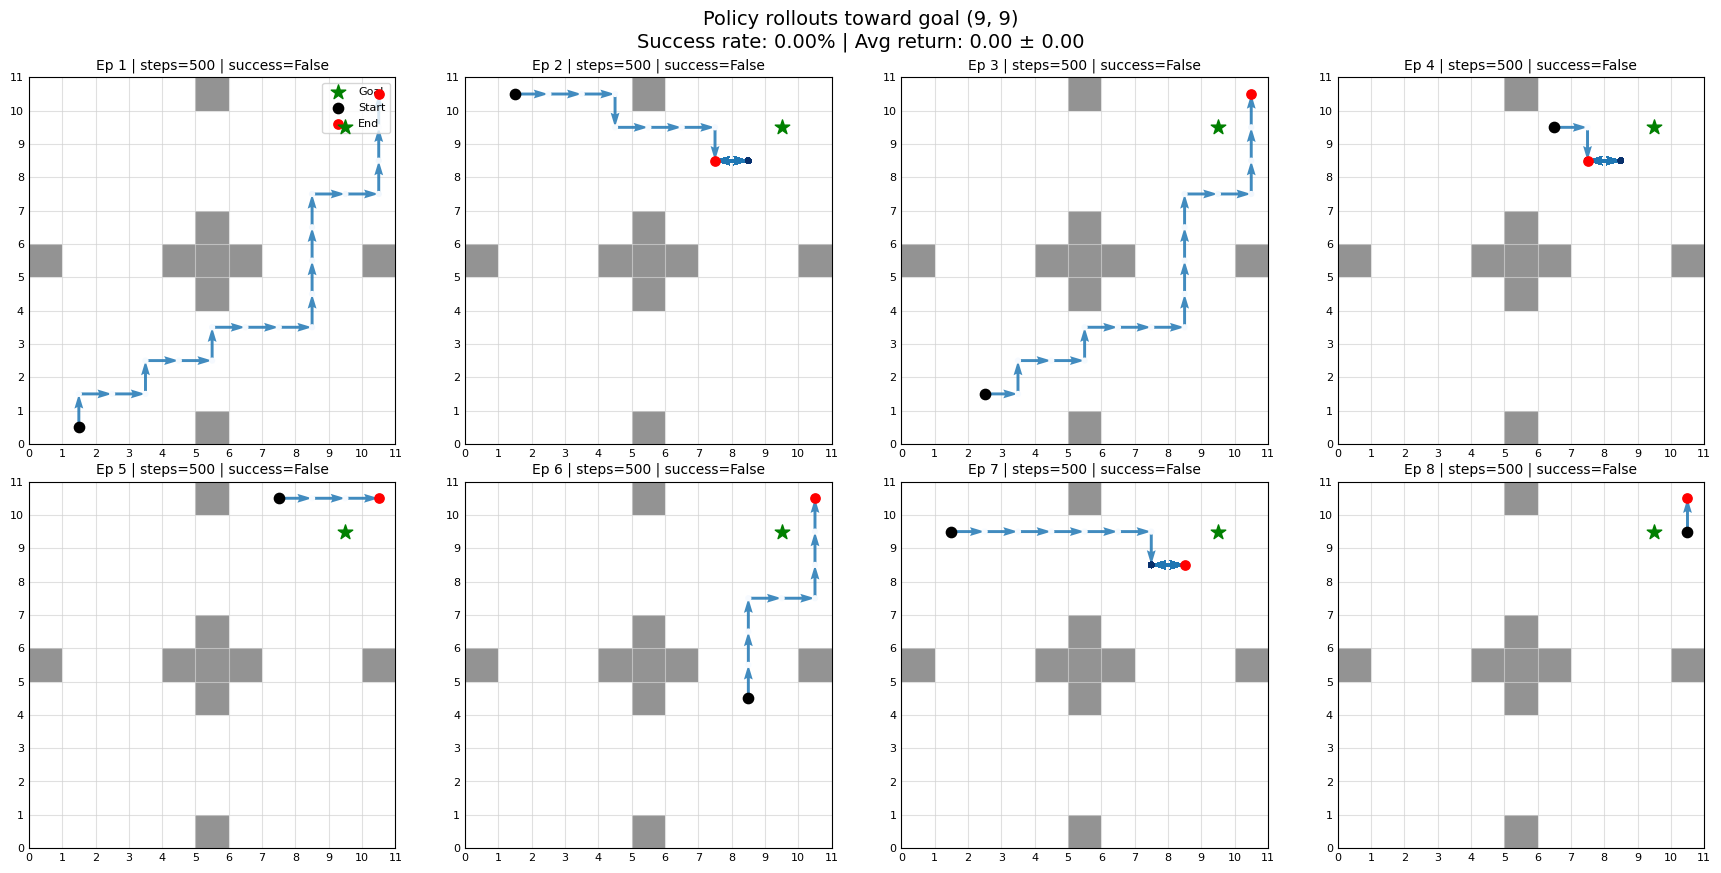

BackwardNetwork(
  (fc_in): Linear(in_features=2, out_features=256, bias=True)
  (hidden): ModuleList(
    (0-1): 2 x Linear(in_features=256, out_features=256, bias=True)
  )
  (fc_out): Linear(in_features=256, out_features=64, bias=True)
)

In [8]:
# Greedy policy wrapper for plot_policy_rollouts
F_net.eval();  B_net.eval()

def fb_greedy_policy(obs_np: np.ndarray) -> int:
    """
    Greedy FB policy for the training goal GOAL_POS.
    Computes  a* = argmax_a  F(s, a)^T z_goal
    where z_goal = B(GOAL_POS) was computed above.
    """
    q = fb_value_fn(np.asarray(obs_np)[None])  # [1, 4]
    return int(np.argmax(q[0]))


print(f"Evaluating greedy FB policy toward training goal {GOAL_POS} ...")
plot_policy_rollouts(
    env             = env_eval,
    policy_fn       = fb_greedy_policy,
    goal_pos        = GOAL_POS,
    eval_episodes   = 8,
    n_cols          = 4,
    is_discrete     = True,
    step_point_size = 12,
)
F_net.train();  B_net.train()


 ## Zero-Shot Transfer Evaluation


--- Transfer to goal (9, 1) (zero-shot) ---


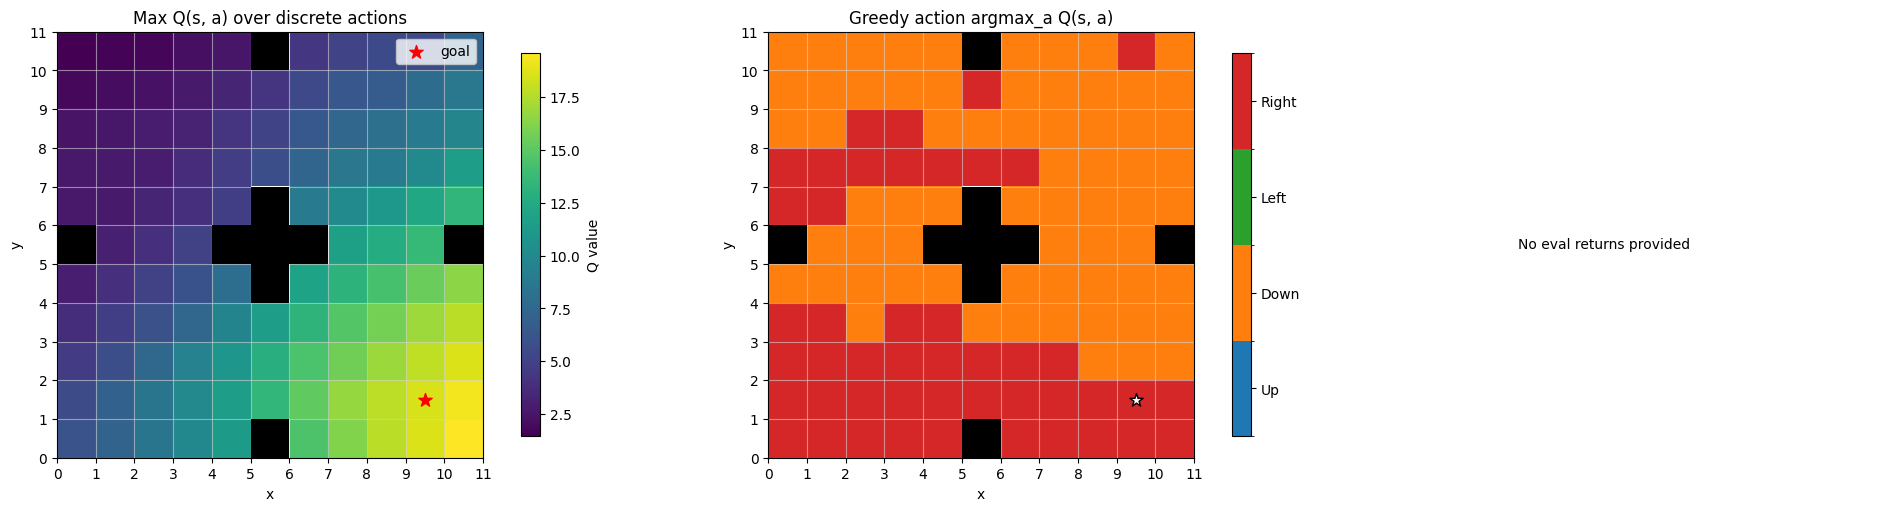

Episode 1: 500 steps | return: 0.00 | reached goal: False
Episode 2: 500 steps | return: 0.00 | reached goal: False
Episode 3: 17 steps | return: 1.00 | reached goal: True
Episode 4: 9 steps | return: 1.00 | reached goal: True
Episode 5: 8 steps | return: 1.00 | reached goal: True
Episode 6: 9 steps | return: 1.00 | reached goal: True
Episode 7: 11 steps | return: 1.00 | reached goal: True
Episode 8: 17 steps | return: 1.00 | reached goal: True

Success rate: 75.00% over 8 episodes
Average return: 0.75 ± 0.43


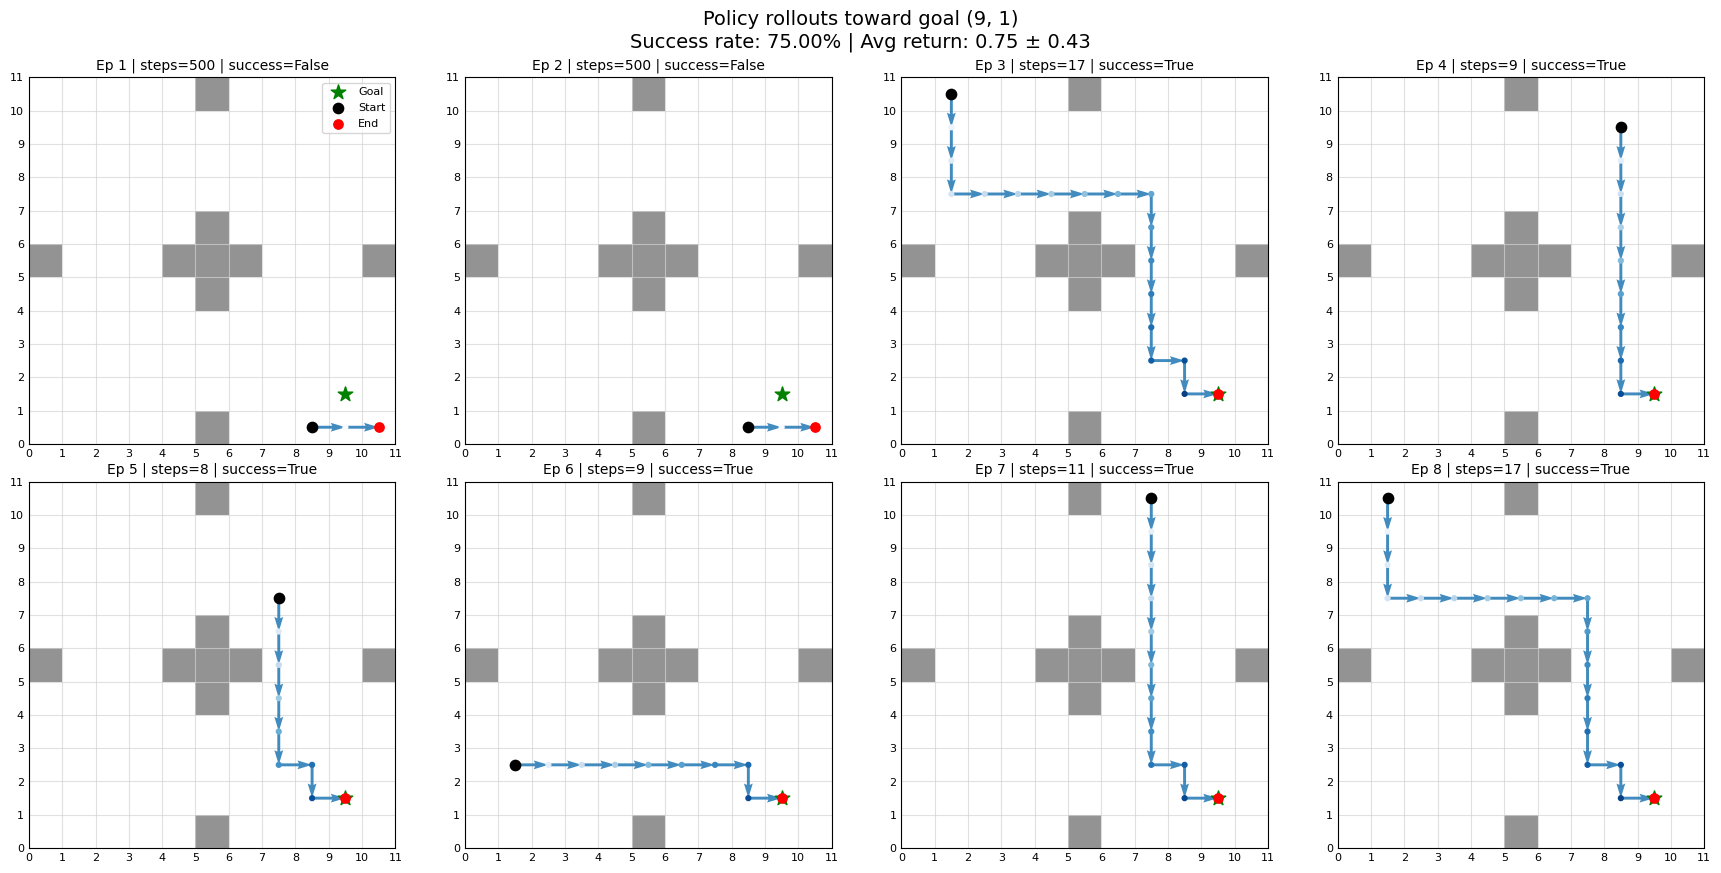


--- Transfer to goal (1, 9) (zero-shot) ---


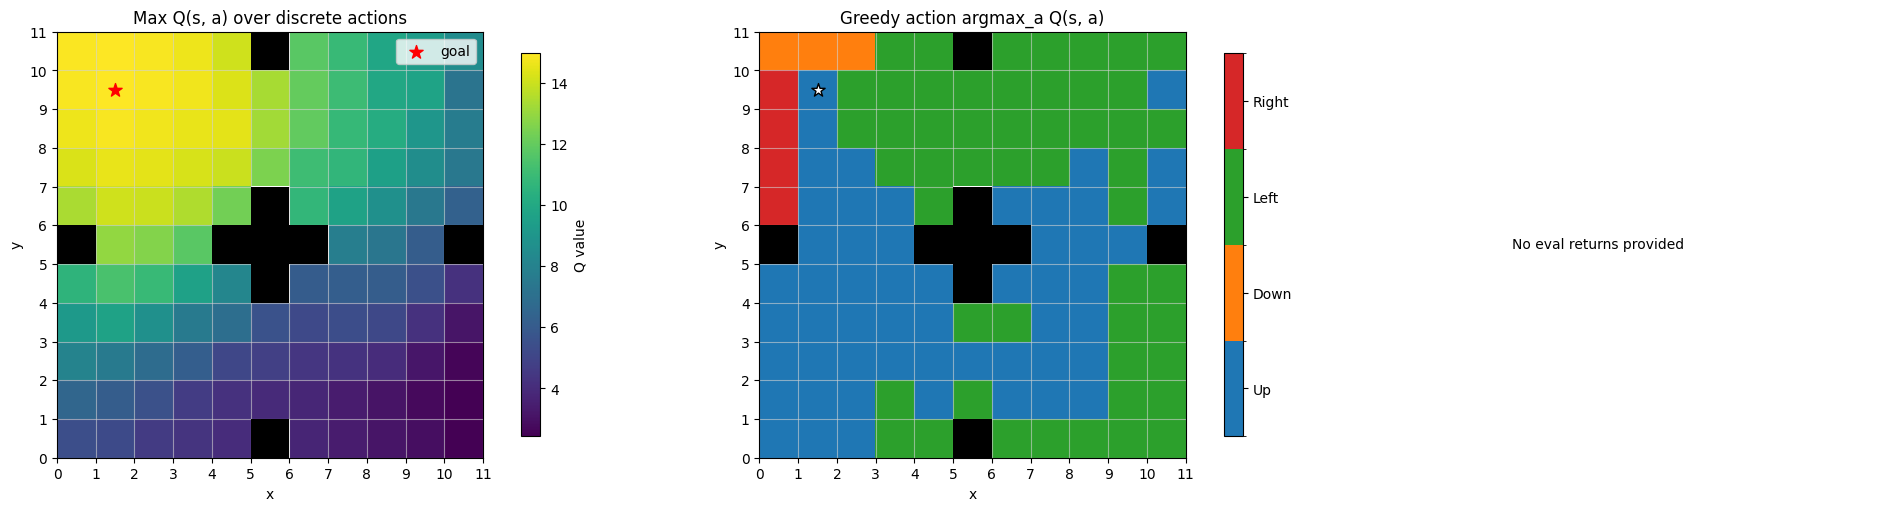

Episode 1: 13 steps | return: 1.00 | reached goal: True
Episode 2: 500 steps | return: 0.00 | reached goal: False
Episode 3: 500 steps | return: 0.00 | reached goal: False
Episode 4: 10 steps | return: 1.00 | reached goal: True
Episode 5: 4 steps | return: 1.00 | reached goal: True
Episode 6: 2 steps | return: 1.00 | reached goal: True
Episode 7: 500 steps | return: 0.00 | reached goal: False
Episode 8: 500 steps | return: 0.00 | reached goal: False

Success rate: 50.00% over 8 episodes
Average return: 0.50 ± 0.50


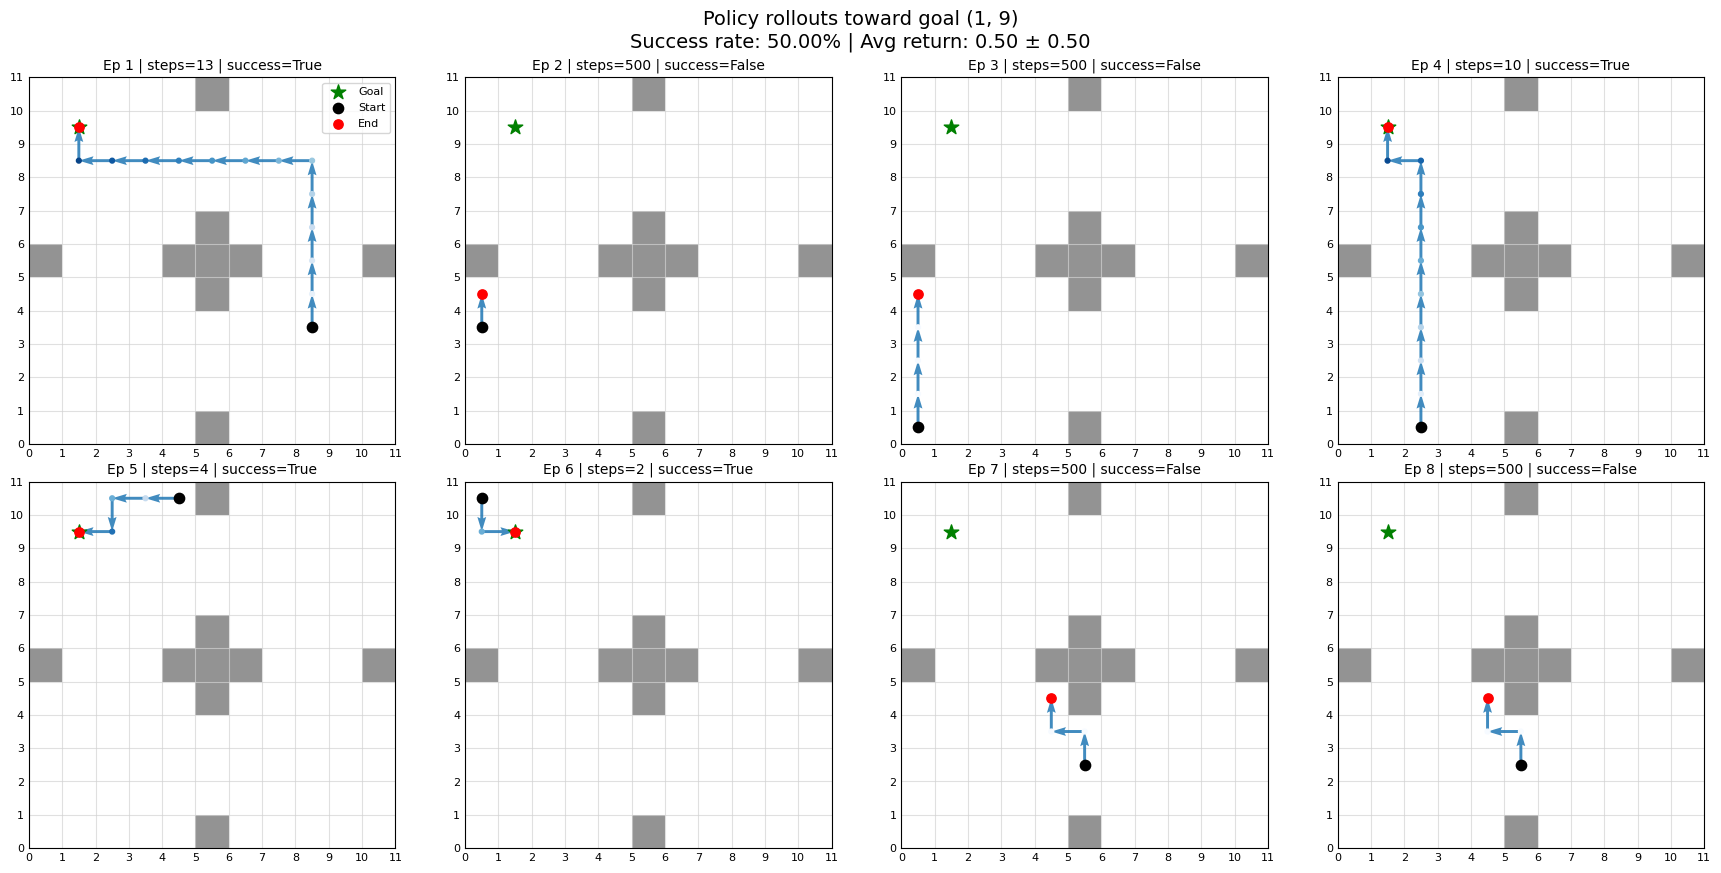

Transfer evaluation complete.


In [9]:
F_net.eval();  B_net.eval()

for transfer_goal in [(9, 1), (1, 9)]:

    # Build transfer environment
    base_tr = FourRoomsGridWorld(room_size=5, max_episode_steps=MAX_EPISODE_STEPS)
    env_tr  = FourRoomsGoalWrapper(
        base_tr, goal_position=transfer_goal, goal_reward=1.0, step_reward=0.0
    )

    # Compute transfer goal embedding  z* = B(g*)  -- the only change needed!
    goal_tr_t = torch.tensor(
        list(transfer_goal), dtype=torch.float32, device=DEVICE
    ).unsqueeze(0)                                             # [1, 2]

    with torch.no_grad():
        z_tr = B_net(goal_tr_t)                               # [1, d]

    # Q-value function for the transfer goal
    def fb_value_fn_tr(obs_batch: np.ndarray) -> np.ndarray:
        """Q(s, a; g*) = F(s,a)^T B(g*) for all actions."""
        obs_t = torch.tensor(
            np.asarray(obs_batch), dtype=torch.float32, device=DEVICE
        )
        N = obs_t.shape[0]
        with torch.no_grad():
            q_mat = compute_all_action_q(
                obs_t, z_tr.expand(N, -1), F_net, num_actions
            )
        return q_mat.cpu().numpy()

    def fb_greedy_tr(obs_np: np.ndarray) -> int:
        """Greedy policy for transfer goal:  a* = argmax_a F(s,a)^T z*"""
        q = fb_value_fn_tr(np.asarray(obs_np)[None])
        return int(np.argmax(q[0]))

    # Q-value heatmap for transfer goal
    print(f"\n--- Transfer to goal {transfer_goal} (zero-shot) ---")
    plot_q_diagnostics(
        env          = env_tr,
        value_fn     = fb_value_fn_tr,
        is_discrete  = True,
        num_actions  = 4,
        action_names = ["Up", "Down", "Left", "Right"],
        goal_pos     = transfer_goal,
        eval_returns = None,
        figsize      = (20, 5),
    )

    # Policy rollouts for transfer goal
    plot_policy_rollouts(
        env             = env_tr,
        policy_fn       = fb_greedy_tr,
        goal_pos        = transfer_goal,
        eval_episodes   = 8,
        n_cols          = 4,
        is_discrete     = True,
        step_point_size = 12,
    )
    env_tr.close()

F_net.train();  B_net.train()
print("Transfer evaluation complete.")
